In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def objective_function(x):
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2 * np.pi * x))
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + 20.0 + np.euler_gamma

In [5]:
def calculate_fitness(obj_val, mode='minimize'):
    if mode == 'minimize':
        if obj_val >= 0:
            return 1.0 / (1.0 + obj_val)
        else:
            return 1.0 + abs(obj_val)
    else:
        return obj_val 

In [6]:
def artificial_bee_colony(mode='minimize', max_iter=50, colony_size=30, limit=20):
    D = 4  
    lb, ub = -5.0, 5.0 
    num_sources = colony_size // 2 
    
    X = np.random.uniform(lb, ub, (num_sources, D))
    obj_values = np.array([objective_function(x) for x in X])
    fitness = np.array([calculate_fitness(v, mode) for v in obj_values])
    trials = np.zeros(num_sources) 
    
    if mode == 'minimize':
        best_idx = np.argmin(obj_values)
    else:
        best_idx = np.argmax(obj_values)
        
    g_best_x = X[best_idx].copy()
    g_best_val = obj_values[best_idx]
    
    history = []
    
    print(f"\n--- ABC RUNNING: MODE = {mode.upper()} ---")
    
    for it in range(max_iter):
        for i in range(num_sources):
            k = np.random.choice([idx for idx in range(num_sources) if idx != i])
            j = np.random.randint(0, D) 
            phi = np.random.uniform(-1, 1) 
            
            v_i = X[i].copy()
            v_i[j] = X[i][j] + phi * (X[i][j] - X[k][j]) 
            v_i[j] = np.clip(v_i[j], lb, ub) 
            
            v_obj = objective_function(v_i)
            v_fit = calculate_fitness(v_obj, mode)
            
            if v_fit > fitness[i]:
                X[i] = v_i
                obj_values[i] = v_obj
                fitness[i] = v_fit
                trials[i] = 0 
            else:
                trials[i] += 1 

        fit_sum = np.sum(fitness)
        prob = fitness / fit_sum if fit_sum != 0 else np.ones(num_sources)/num_sources
        
        m = 0
        while m < num_sources:
            i = np.random.choice(num_sources, p=prob)
            k = np.random.choice([idx for idx in range(num_sources) if idx != i])
            j = np.random.randint(0, D)
            phi = np.random.uniform(-1, 1)
            
            v_i = X[i].copy()
            v_i[j] = X[i][j] + phi * (X[i][j] - X[k][j])
            v_i[j] = np.clip(v_i[j], lb, ub)
            
            v_obj = objective_function(v_i)
            v_fit = calculate_fitness(v_obj, mode)
            
            if v_fit > fitness[i]:
                X[i] = v_i
                obj_values[i] = v_obj
                fitness[i] = v_fit
                trials[i] = 0
            else:
                trials[i] += 1
            m += 1

        if mode == 'minimize':
            current_best_idx = np.argmin(obj_values)
            if obj_values[current_best_idx] < g_best_val:
                g_best_val = obj_values[current_best_idx]
                g_best_x = X[current_best_idx].copy()
        else: 
            current_best_idx = np.argmax(obj_values)
            if obj_values[current_best_idx] > g_best_val:
                g_best_val = obj_values[current_best_idx]
                g_best_x = X[current_best_idx].copy()
                
        max_trial_idx = np.argmax(trials)
        if trials[max_trial_idx] > limit:
            X[max_trial_idx] = np.random.uniform(lb, ub, D)
            obj_values[max_trial_idx] = objective_function(X[max_trial_idx])
            fitness[max_trial_idx] = calculate_fitness(obj_values[max_trial_idx], mode)
            trials[max_trial_idx] = 0
            
        history.append(g_best_val)
        print(f"Iteration {it+1:02d}: Best Value = {g_best_val:.6f} | Variables = {np.round(g_best_x, 3)}")
        
    return history


In [7]:
min_history = artificial_bee_colony(mode='minimize', max_iter=50)
max_history = artificial_bee_colony(mode='maximize', max_iter=50)



--- ABC RUNNING: MODE = MINIMIZE ---
Iteration 01: Best Value = 3.322589 | Variables = [ 1.23  -1.462 -0.006  0.452]
Iteration 02: Best Value = 1.202893 | Variables = [-0.293 -0.96  -0.006  0.32 ]
Iteration 03: Best Value = -0.159672 | Variables = [-0.238  0.115 -0.006  0.284]
Iteration 04: Best Value = -0.480869 | Variables = [-0.238  0.115 -0.006  0.199]
Iteration 05: Best Value = -0.892434 | Variables = [-0.238  0.115 -0.006 -0.052]
Iteration 06: Best Value = -1.054054 | Variables = [-0.238 -0.042 -0.006 -0.046]
Iteration 07: Best Value = -1.054054 | Variables = [-0.238 -0.042 -0.006 -0.046]
Iteration 08: Best Value = -1.802323 | Variables = [ 0.081 -0.042 -0.006 -0.046]
Iteration 09: Best Value = -1.838201 | Variables = [ 0.081 -0.042 -0.006 -0.023]
Iteration 10: Best Value = -2.084279 | Variables = [-0.003  0.006 -0.006 -0.023]
Iteration 11: Best Value = -2.085326 | Variables = [-0.003 -0.004 -0.006 -0.023]
Iteration 12: Best Value = -2.124305 | Variables = [-0.003 -0.004 -0.006 

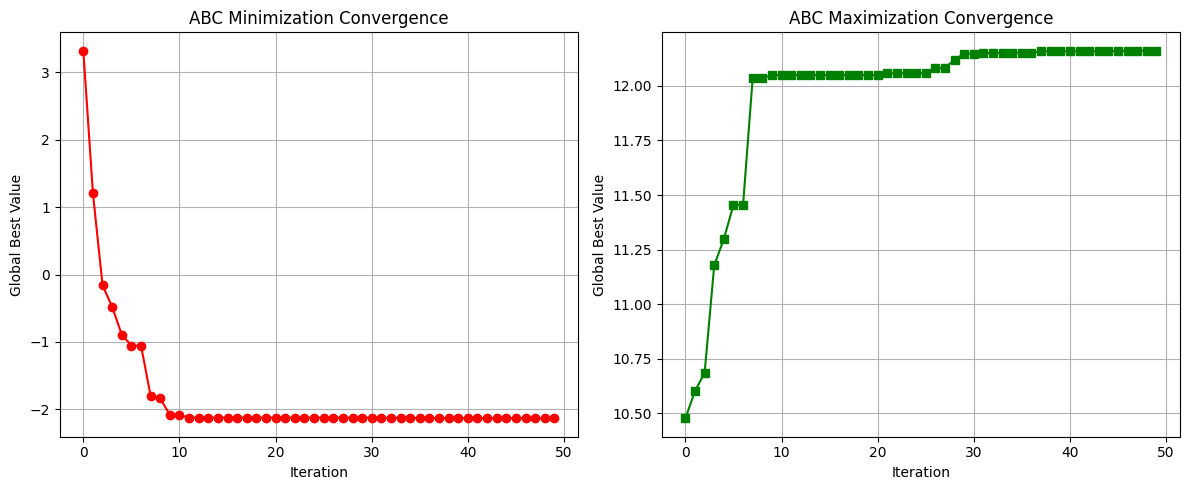

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(min_history, color='red', marker='o', linestyle='-')
plt.title('ABC Minimization Convergence')
plt.xlabel('Iteration')
plt.ylabel('Global Best Value')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(max_history, color='green', marker='s', linestyle='-')
plt.title('ABC Maximization Convergence')
plt.xlabel('Iteration')
plt.ylabel('Global Best Value')
plt.grid(True)

plt.tight_layout()
plt.show()